In [1]:
from google.colab import drive
drive.mount('/content/drive')
#/content/drive/MyDrive/Thesis/figures/
# /content/drive/MyDrive/Thesis/datasets/
# /content/drive/MyDrive/Thesis/pickles/

Mounted at /content/drive


In [2]:
pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.1 MB/s eta 0:00:00


In [3]:
import pandas as pd
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import Metadata

train_dataset = '/content/drive/MyDrive/Thesis/datasets/german_credit_train.csv'
df = pd.read_csv(train_dataset)

In [4]:
metadata = Metadata.detect_from_dataframe(
    data=df,
    table_name='german_credit')
print(metadata)

{
    "tables": {
        "german_credit": {
            "columns": {
                "checking_account_status": {
                    "sdtype": "categorical"
                },
                "duration_months": {
                    "sdtype": "numerical"
                },
                "credit_history": {
                    "sdtype": "categorical"
                },
                "purpose": {
                    "sdtype": "categorical"
                },
                "credit_amount": {
                    "sdtype": "numerical"
                },
                "savings_account": {
                    "sdtype": "categorical"
                },
                "employment_duration": {
                    "sdtype": "categorical"
                },
                "installment_rate": {
                    "sdtype": "categorical"
                },
                "sex": {
                    "sdtype": "categorical"
                },
                "other_debtors": {
         

In [5]:
synthesizer = CTGANSynthesizer(metadata,epochs=1000,embedding_dim=512,generator_lr=1e-4,discriminator_lr=1e-4,verbose=True)
synthesizer.fit(df)

synthetic_data = synthesizer.sample(num_rows=1000)
synthetic_data.to_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=512+lr=1e-4_testy).csv', index=False)
synthesizer.save(filepath='/content/drive/MyDrive/Thesis/pickles/synthesizer_epoch=1000+embedding_dim=512+lr=1e-4_testy.pkl')

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (-00.85) | Discrim. (-00.05): 100%|██████████| 1000/1000 [01:54<00:00,  8.72it/s]


In [7]:
from sdv.evaluation.single_table import run_diagnostic
from sdv.evaluation.single_table import evaluate_quality

diagnostic = run_diagnostic(
    real_data=df,
    synthetic_data=synthetic_data,
    metadata=metadata
)
quality_report = evaluate_quality(
    df,
    synthetic_data,
    metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 22/22 [00:00<00:00, 1478.17it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 264.86it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 22/22 [00:00<00:00, 961.79it/s]|
Column Shapes Score: 92.89%

(2/2) Evaluating Column Pair Trends: |██████████| 231/231 [00:00<00:00, 337.37it/s]|
Column Pair Trends Score: 75.15%

Overall Score (Average): 84.02%



In [8]:

fig = synthesizer.get_loss_values_plot(title='CTGAN loss function(default)')
fig.show()


In [9]:
from sdv.evaluation.single_table import get_column_plot
fig = get_column_plot(
    real_data=df,
    synthetic_data=synthetic_data,
    column_name='target',
    metadata=metadata
)

fig.show()

In [11]:
print(df.columns)

Index(['checking_account_status', 'duration_months', 'credit_history',
       'purpose', 'credit_amount', 'savings_account', 'employment_duration',
       'installment_rate', 'sex', 'other_debtors', 'residence_duration',
       'property', 'age', 'other_installment_plans', 'housing',
       'existing_credits', 'job', 'num_dependents', 'telephone',
       'foreign_worker', 'target', 'relationship status'],
      dtype='object')


,duration_months
0,27
1,27
2,26
3,20
4,28
...,...
995,26
996,15
997,26
998,26


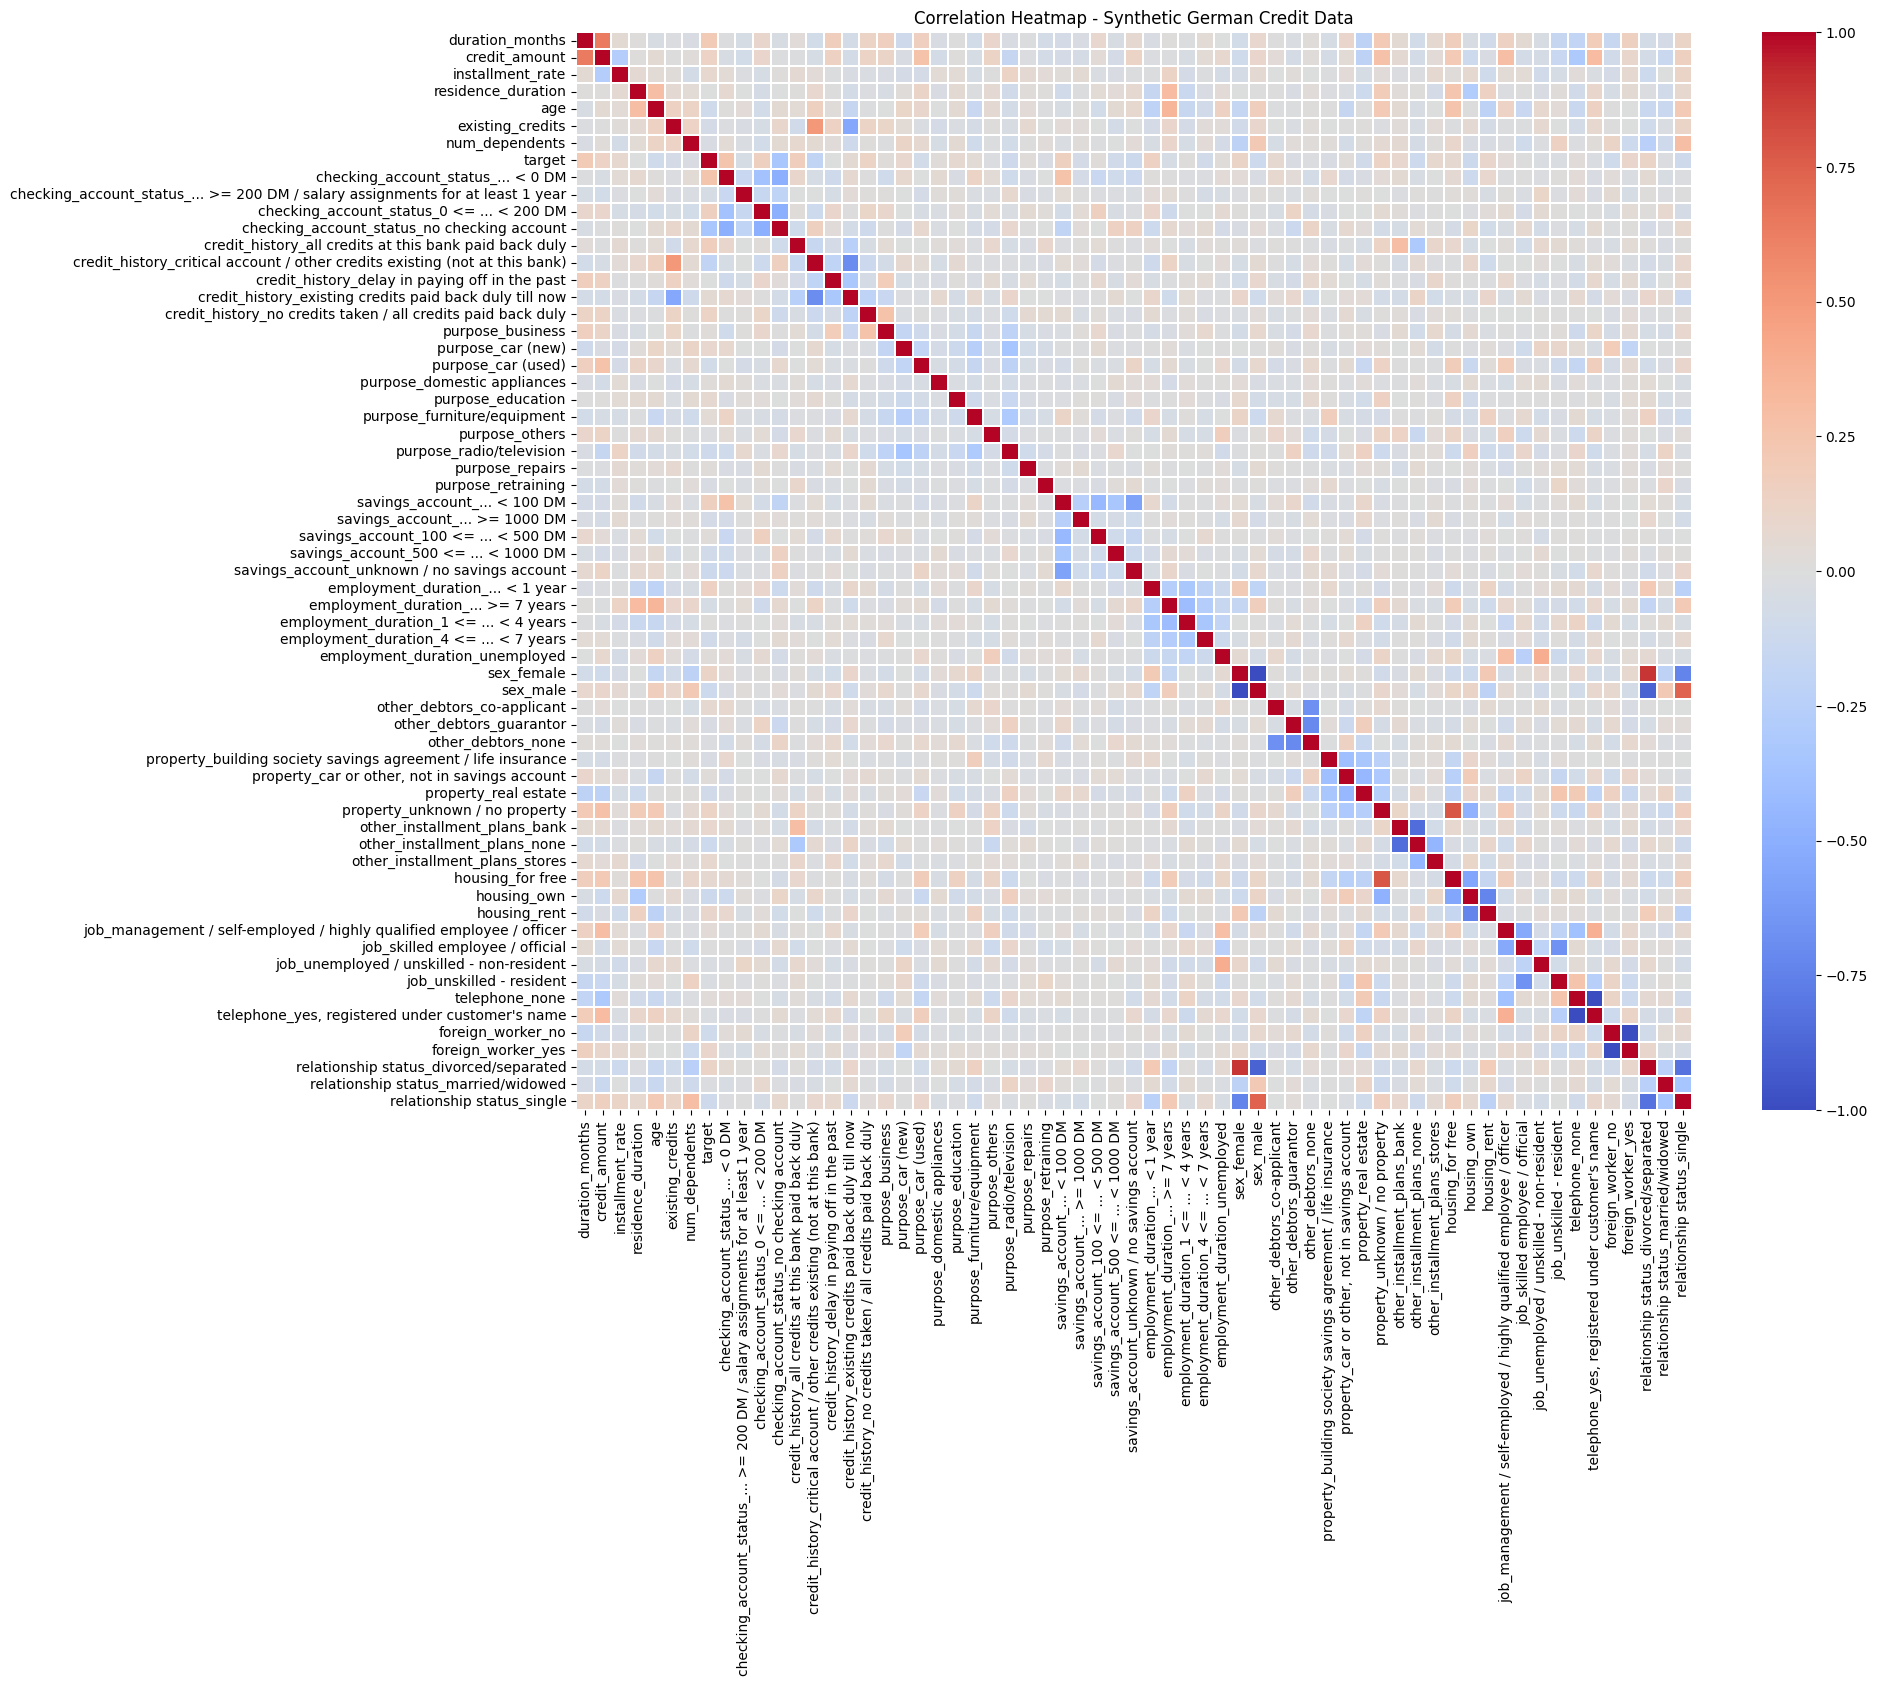

In [13]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Make a copy
# df_corr = df.copy()

# # One-hot encode categorical columns, including target if it is categorical
# df_encoded = pd.get_dummies(df_corr, drop_first=False)

# # Correlation matrix
# corr = df_encoded.corr()

# # Plot heatmap
# plt.figure(figsize=(18, 14))
# sns.heatmap(
#     corr,
#     cmap="coolwarm",
#     center=0,
#     linewidths=0.3
# )

# plt.title("Correlation Heatmap - Synthetic German Credit Data")
# plt.show()

In [39]:
categorical_cols = [
    'checking_account_status', 'credit_history', 'purpose', 'savings_account',
    'employment_duration', 'sex', 'other_debtors', 'property',
    'other_installment_plans', 'housing', 'job', 'telephone',
    'foreign_worker', 'target', 'relationship status'
]

continuous_cols = [
    'duration_months', 'credit_amount', 'installment_rate',
    'residence_duration', 'age', 'existing_credits', 'num_dependents'
]

synthetic_datasets = {
    'config default': pd.read_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data_default(epochs300).csv'),
    'config #1': pd.read_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs100).csv'),
    'config #2': pd.read_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs500).csv'),
    'config #3': pd.read_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000).csv'),
    'config #4': pd.read_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=256).csv'),
    'config #5': pd.read_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=512).csv'),
    'config #6': pd.read_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=512+lr=2e-6).csv'),
    'config #7': pd.read_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=512+lr=2e-3).csv'),
    'config #8': pd.read_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=512+lr=1e-4).csv'),
    'config #9': pd.read_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=512+lr=1e-6).csv'),
    'config_new': synthetic_data,
    'config_new2': synthetic_data23
}

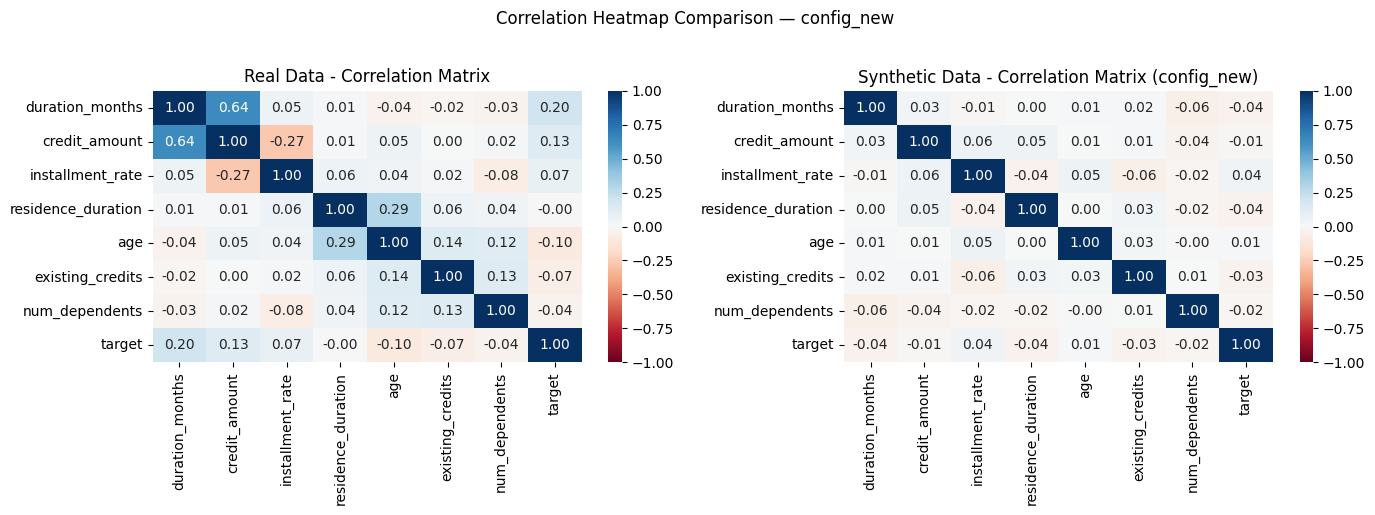

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define which config you want
syn_df = synthetic_datasets['config_new']
config_name = 'config_new'

# Real data correlation
real_corr_df = df[continuous_cols].copy()
real_corr_df['target'] = df['target']
real_corr = real_corr_df.corr()

# Synthetic data correlation
syn_corr_df = syn_df[continuous_cols].copy()
syn_corr_df['target'] = syn_df['target']
syn_corr = syn_corr_df.corr()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(real_corr, annot=True, fmt='.2f', cmap='RdBu',
            vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Real Data - Correlation Matrix')

sns.heatmap(syn_corr, annot=True, fmt='.2f', cmap='RdBu',
            vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title(f'Synthetic Data - Correlation Matrix ({config_name})')

plt.suptitle(f'Correlation Heatmap Comparison — {config_name}', y=1.02)
plt.tight_layout()
plt.savefig(f"/content/drive/MyDrive/Thesis/figures/correlation_heatmap_{config_name}.pdf",
            bbox_inches='tight', dpi=300)
plt.show()

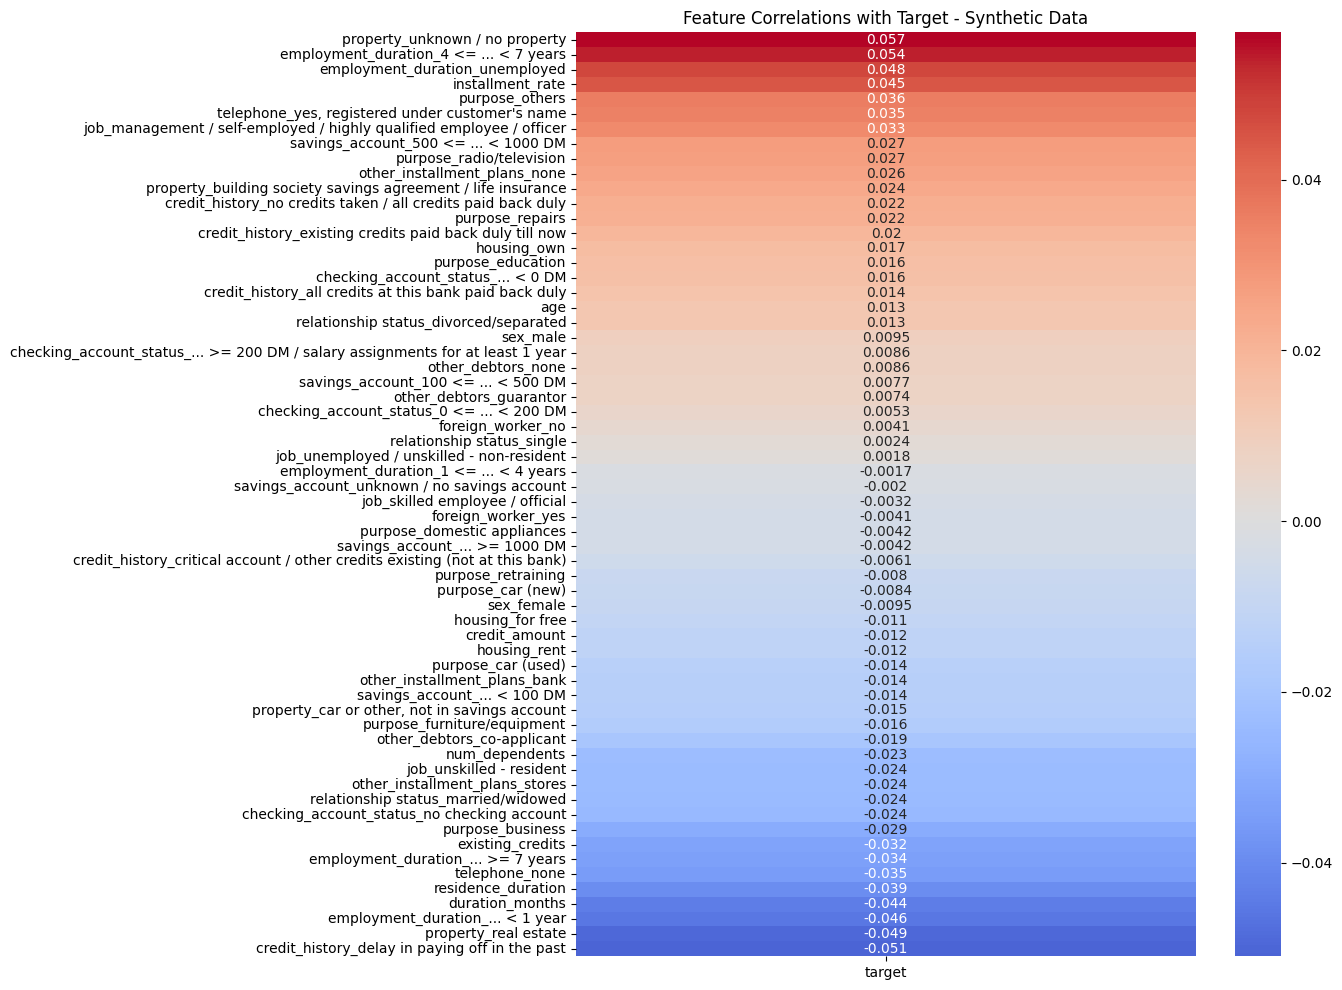

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_corr = synthetic_data.copy()

# One-hot encode only feature columns, keep numeric target as-is
X_encoded = pd.get_dummies(df_corr.drop(columns=["target"]), drop_first=False)

df_encoded = pd.concat(
    [X_encoded, df_corr["target"]],
    axis=1
)

corr = df_encoded.corr()

# Correlations with target
target_corr = corr["target"].sort_values(ascending=False)
target_corr = target_corr.drop(index="target")

plt.figure(figsize=(10, 12))
sns.heatmap(
    target_corr.to_frame(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlations with Target - Synthetic Data")
plt.show()

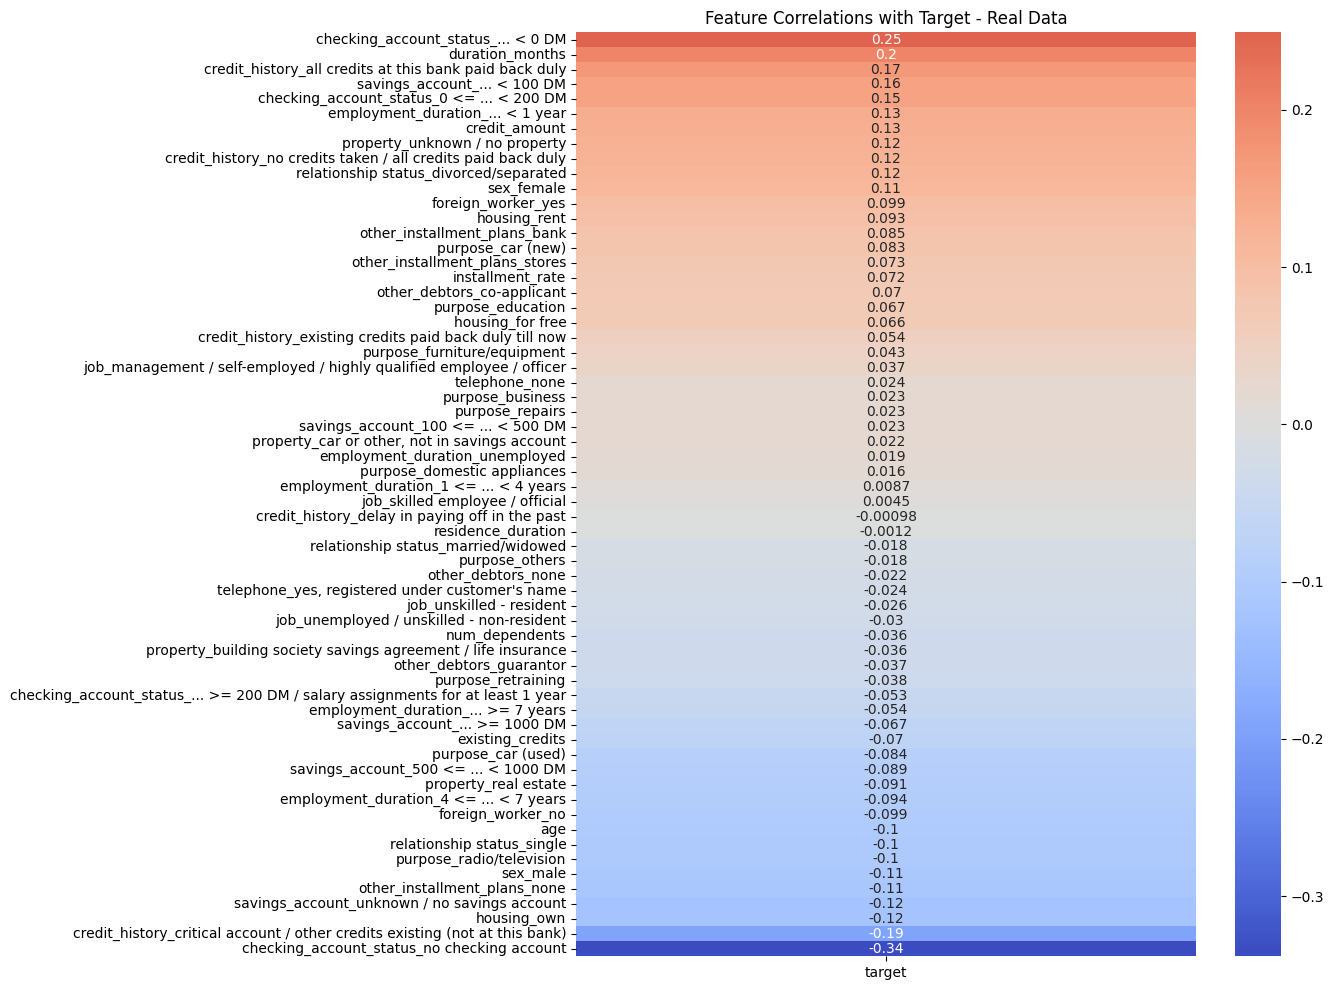

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_corr = df.copy()

# One-hot encode only feature columns, keep numeric target as-is
X_encoded = pd.get_dummies(df_corr.drop(columns=["target"]), drop_first=False)

df_encoded = pd.concat(
    [X_encoded, df_corr["target"]],
    axis=1
)

corr = df_encoded.corr()

# Correlations with target
target_corr = corr["target"].sort_values(ascending=False)
target_corr = target_corr.drop(index="target")

plt.figure(figsize=(10, 12))
sns.heatmap(
    target_corr.to_frame(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlations with Target - Real Data")
plt.show()

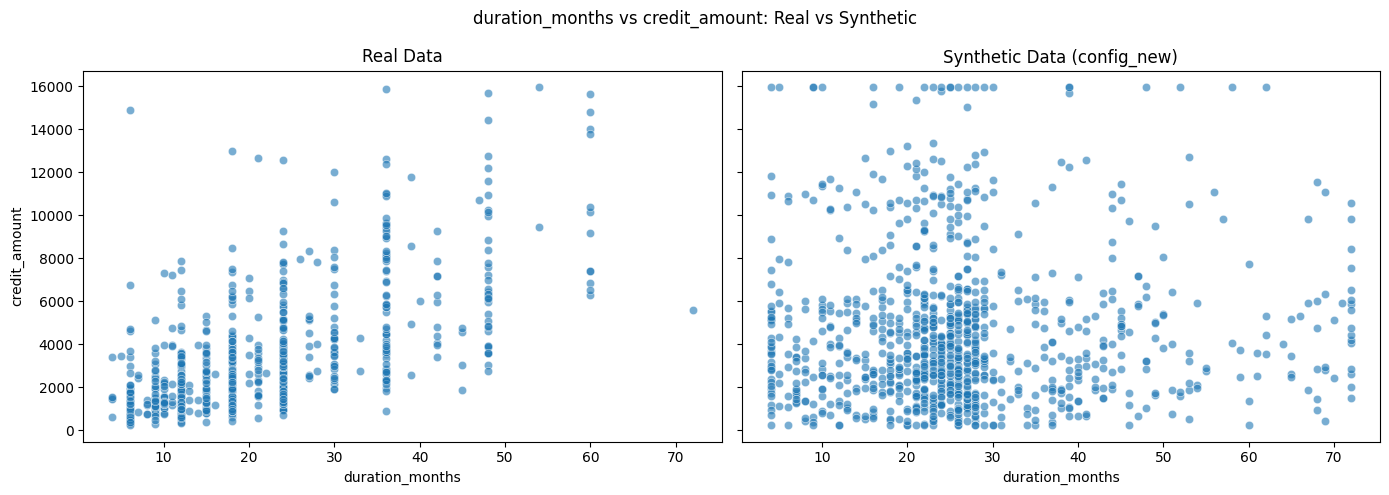

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose synthetic config
syn_df = synthetic_datasets['config_new']
config_name = 'config_new'

# Columns to compare
x_col = 'duration_months'
y_col = 'credit_amount'

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

# Real data
sns.scatterplot(
    data=df,
    x=x_col,
    y=y_col,
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title('Real Data')
axes[0].set_xlabel(x_col)
axes[0].set_ylabel(y_col)

# Synthetic data
sns.scatterplot(
    data=syn_df,
    x=x_col,
    y=y_col,
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title(f'Synthetic Data ({config_name})')
axes[1].set_xlabel(x_col)
axes[1].set_ylabel(y_col)

plt.suptitle(f'{x_col} vs {y_col}: Real vs Synthetic')
plt.tight_layout()
plt.show()

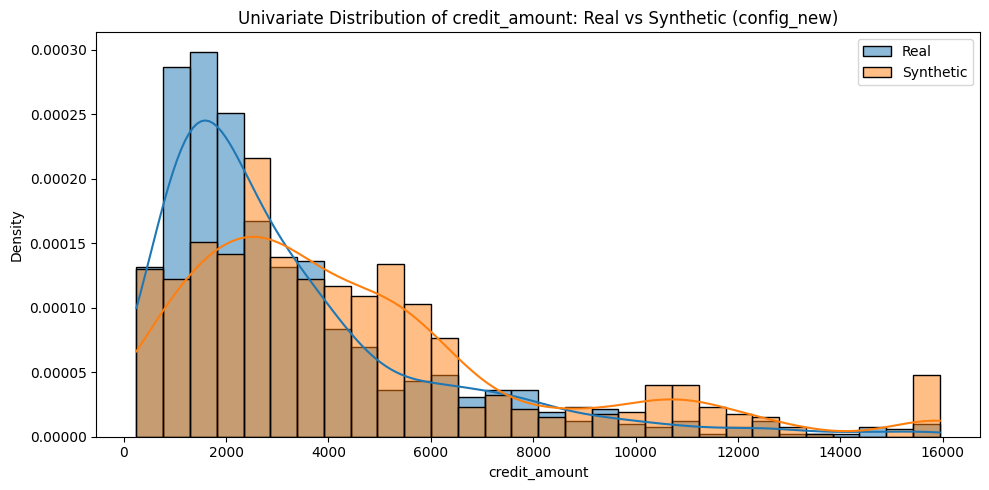

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose synthetic config
syn_df = synthetic_datasets['config_new']
config_name = 'config_new'

# Column to compare
col = 'credit_amount'

plt.figure(figsize=(10, 5))

sns.histplot(
    df[col],
    label='Real',
    kde=True,
    stat='density',
    alpha=0.5,
    bins=30
)

sns.histplot(
    syn_df[col],
    label='Synthetic',
    kde=True,
    stat='density',
    alpha=0.5,
    bins=30
)

plt.title(f'Univariate Distribution of {col}: Real vs Synthetic ({config_name})')
plt.xlabel(col)
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
import pickle
import pandas as pd
from sdv.utils import load_synthesizer

synth2 = load_synthesizer(
    filepath='/content/drive/MyDrive/Thesis/pickles/synthesizer_epoch=1000+embedding_dim=512+lr=1e-4.pkl'
)
synthdata2 = synth2.sample(1000)

/usr/local/lib/python3.12/dist-packages/sdv/_utils.py:313: SDVVersionWarning:

You are currently on SDV version 1.36.1 but this synthesizer was created on version 1.36.0. The latest bug fixes and features may not be available for this synthesizer. To see these enhancements, create and train a new synthesizer on this version.



In [34]:
synthdata2.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,sex,other_debtors,...,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target,relationship status
0,0 <= ... < 200 DM,4,delay in paying off in the past,car (used),1751,... < 100 DM,1 <= ... < 4 years,4,female,none,...,28,bank,own,2,unskilled - resident,1,none,yes,1,single
1,0 <= ... < 200 DM,13,existing credits paid back duly till now,repairs,1932,... < 100 DM,unemployed,3,male,none,...,29,none,own,1,skilled employee / official,2,none,yes,1,single
2,no checking account,57,existing credits paid back duly till now,furniture/equipment,1012,... < 100 DM,1 <= ... < 4 years,4,male,none,...,30,none,own,2,unskilled - resident,1,none,yes,1,single
3,0 <= ... < 200 DM,4,existing credits paid back duly till now,car (new),250,... < 100 DM,... >= 7 years,2,male,none,...,46,none,own,1,management / self-employed / highly qualified ...,1,none,yes,1,single
4,no checking account,9,existing credits paid back duly till now,furniture/equipment,250,... < 100 DM,... < 1 year,2,male,guarantor,...,37,bank,own,2,skilled employee / official,1,"yes, registered under customer's name",yes,1,divorced/separated


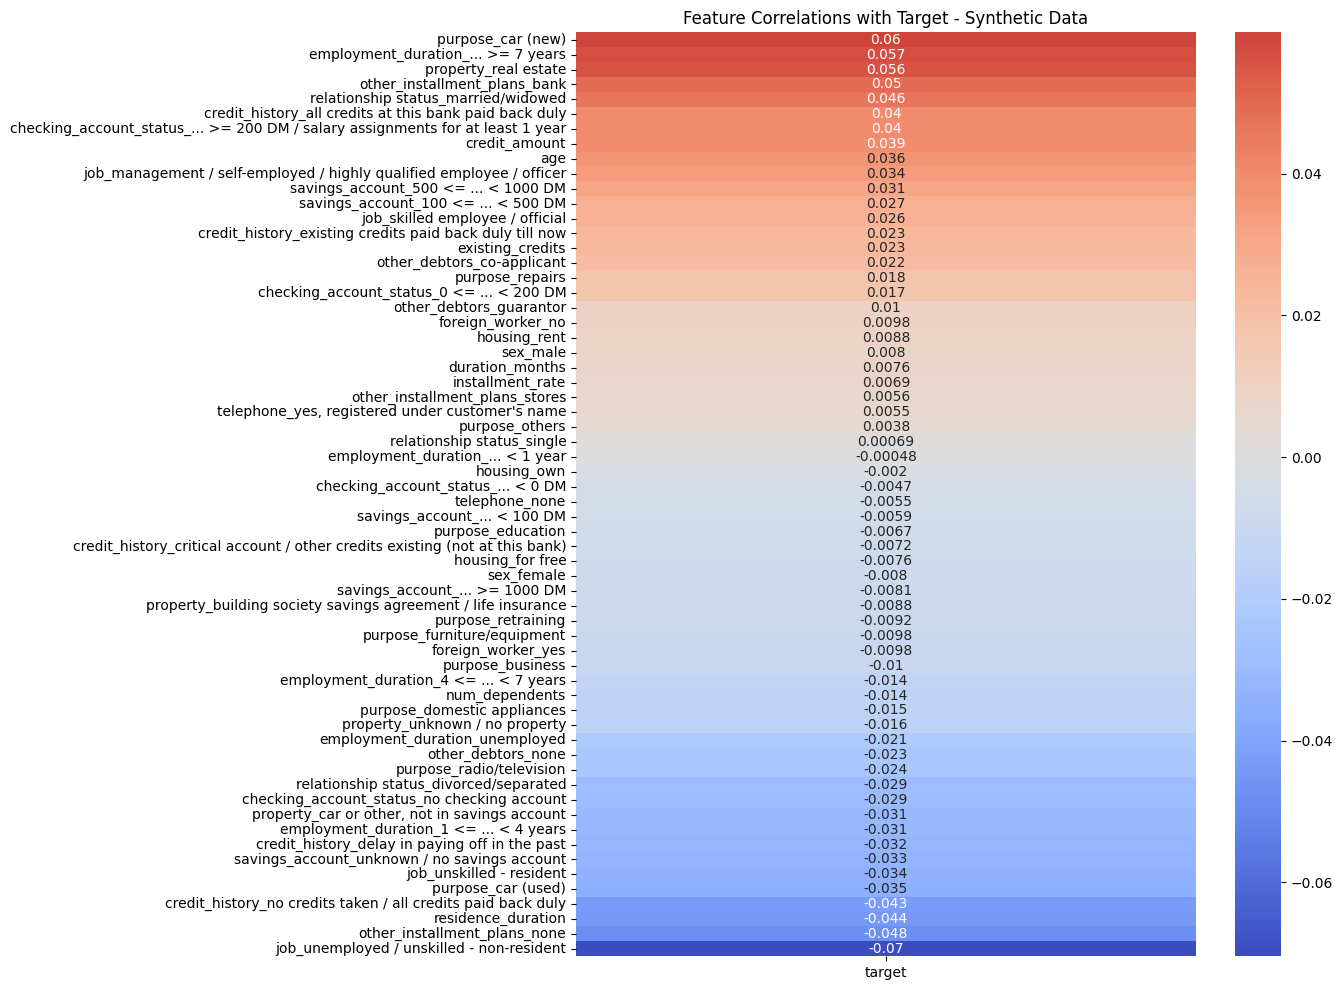

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_corr = synthdata2.copy()

# One-hot encode only feature columns, keep numeric target as-is
X_encoded = pd.get_dummies(df_corr.drop(columns=["target"]), drop_first=False)

df_encoded = pd.concat(
    [X_encoded, df_corr["target"]],
    axis=1
)

corr = df_encoded.corr()

# Correlations with target
target_corr = corr["target"].sort_values(ascending=False)
target_corr = target_corr.drop(index="target")

plt.figure(figsize=(10, 12))
sns.heatmap(
    target_corr.to_frame(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlations with Target - Synthetic Data")
plt.show()

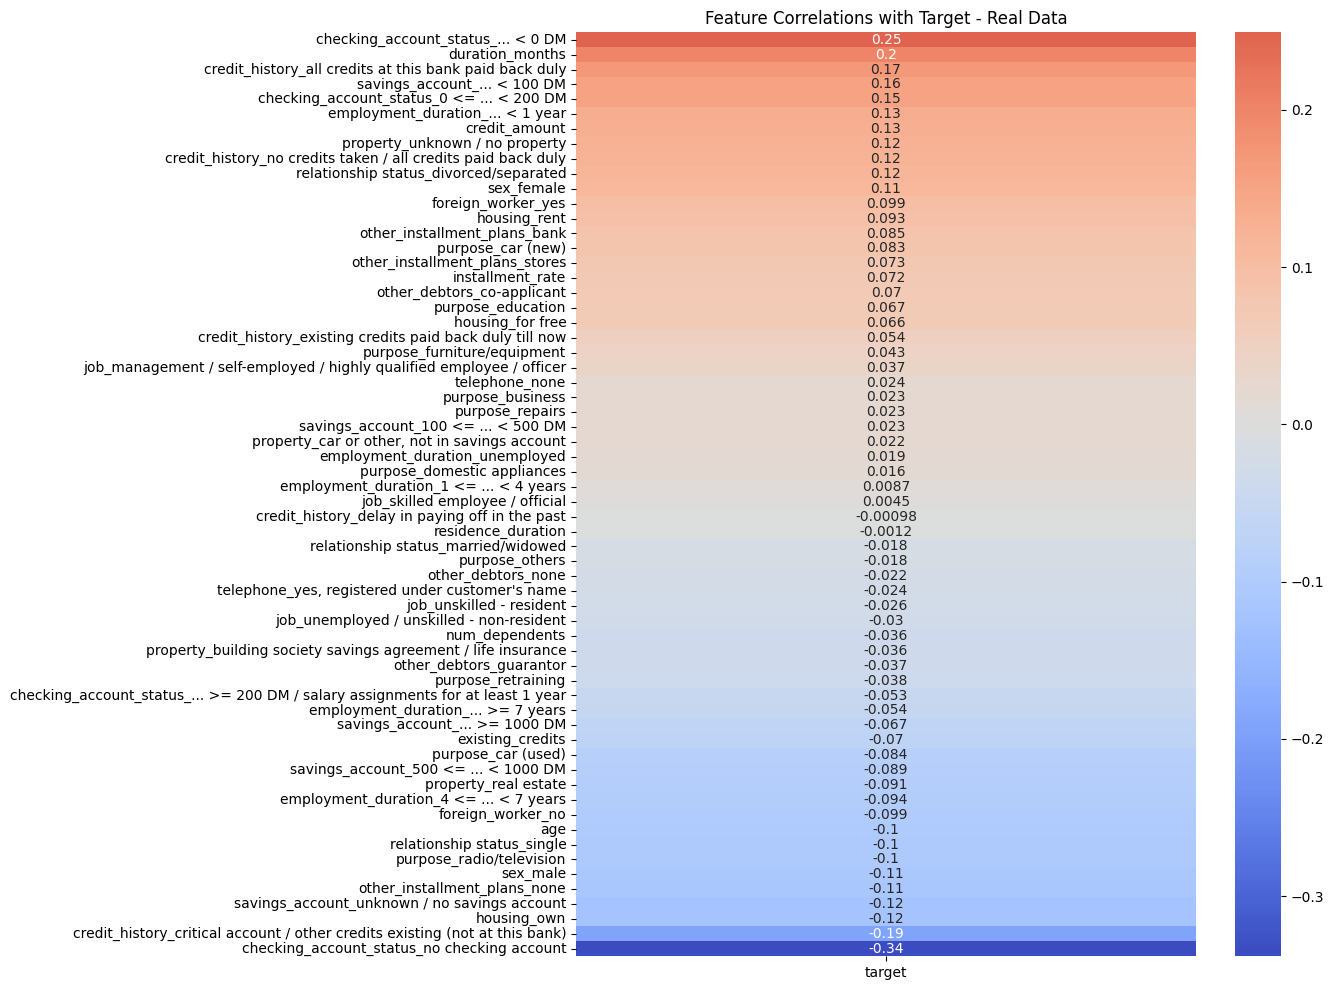

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_corr = df.copy()

# One-hot encode only feature columns, keep numeric target as-is
X_encoded = pd.get_dummies(df_corr.drop(columns=["target"]), drop_first=False)

df_encoded = pd.concat(
    [X_encoded, df_corr["target"]],
    axis=1
)

corr = df_encoded.corr()

# Correlations with target
target_corr = corr["target"].sort_values(ascending=False)
target_corr = target_corr.drop(index="target")

plt.figure(figsize=(10, 12))
sns.heatmap(
    target_corr.to_frame(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlations with Target - Real Data")
plt.show()

In [38]:
from sdv.constraints import ScalarRange

constraint = ScalarRange(
    column_name='credit_amount',
    low_value=150,       # real data minimum
    high_value=16000,    # clip the tail
    strict_boundaries=True
)

# 1e-4 LR for both
synthesizer23 = CTGANSynthesizer(metadata,epochs=1000,embedding_dim=512,generator_lr=1e-4,discriminator_lr=1e-4,verbose=True)
synthesizer23.fit(df)

synthetic_data23 = synthesizer.sample(num_rows=1000)
synthetic_data.to_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=512+lr=1e-423).csv', index=False)
synthesizer.save(filepath='/content/drive/MyDrive/Thesis/pickles/synthesizer_epoch=1000+embedding_dim=512+lr=1e-423.pkl')

/usr/local/lib/python3.12/dist-packages/sdv/constraints/tabular.py:1149: FutureWarning:


Gen. (-00.20) | Discrim. (+00.03): 100%|██████████| 1000/1000 [02:38<00:00,  6.29it/s]


In [42]:
categorical_cols = [
    'checking_account_status', 'credit_history', 'purpose', 'savings_account',
    'employment_duration', 'sex', 'other_debtors', 'property',
    'other_installment_plans', 'housing', 'job', 'telephone',
    'foreign_worker', 'target', 'relationship status'
]

continuous_cols = [
    'duration_months', 'credit_amount', 'installment_rate',
    'residence_duration', 'age', 'existing_credits', 'num_dependents'
]

synthetic_datasets = {
    'config default': pd.read_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data_default(epochs300).csv'),
    'config #1': pd.read_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs100).csv'),
    'config #2': pd.read_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs500).csv'),
    'config #3': pd.read_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000).csv'),
    'config #4': pd.read_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=256).csv'),
    'config #5': pd.read_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=512).csv'),
    'config #6': pd.read_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=512+lr=2e-6).csv'),
    'config #7': pd.read_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=512+lr=2e-3).csv'),
    'config #8': pd.read_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=512+lr=1e-4).csv'),
    'config #9': pd.read_csv('/content/drive/MyDrive/Thesis/datasets/synthetic_data(epochs1000+embedding_dim=512+lr=1e-6).csv'),
    'config_new': synthetic_data,
    'config_new2': synthetic_data23
}

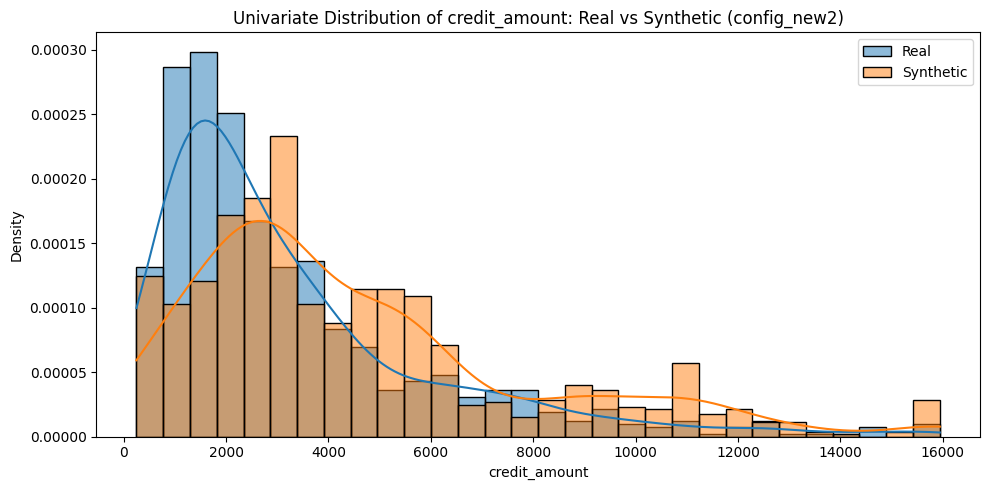

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose synthetic config
syn_df = synthetic_datasets['config_new2']
config_name = 'config_new2'

# Column to compare
col = 'credit_amount'

plt.figure(figsize=(10, 5))

sns.histplot(
    df[col],
    label='Real',
    kde=True,
    stat='density',
    alpha=0.5,
    bins=30
)

sns.histplot(
    syn_df[col],
    label='Synthetic',
    kde=True,
    stat='density',
    alpha=0.5,
    bins=30
)

plt.title(f'Univariate Distribution of {col}: Real vs Synthetic ({config_name})')
plt.xlabel(col)
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

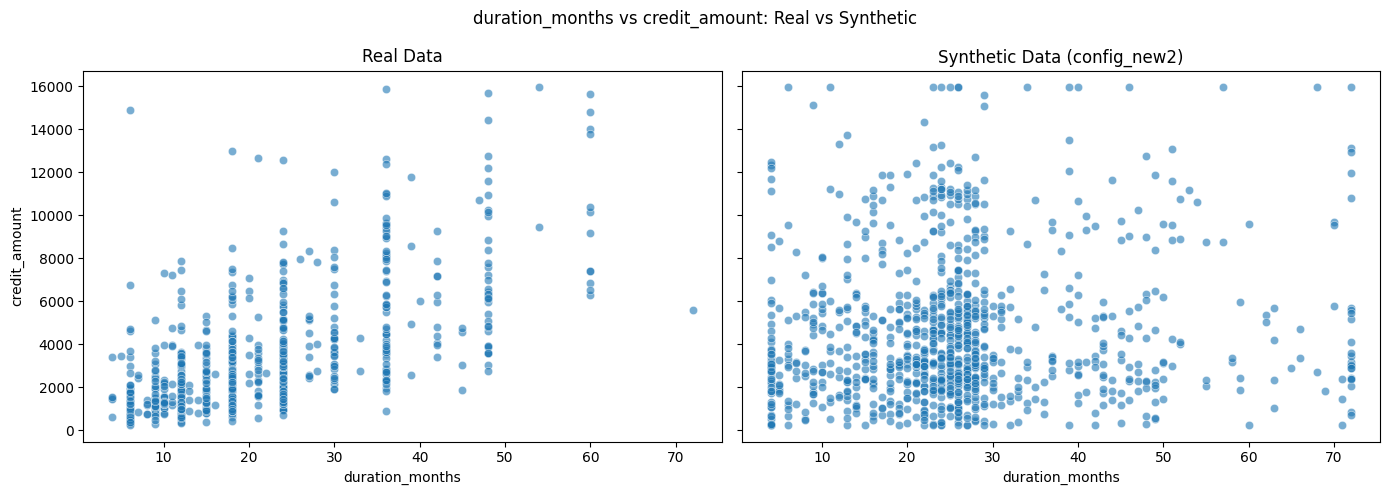

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose synthetic config
syn_df = synthetic_datasets['config_new2']
config_name = 'config_new2'

# Columns to compare
x_col = 'duration_months'
y_col = 'credit_amount'

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

# Real data
sns.scatterplot(
    data=df,
    x=x_col,
    y=y_col,
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title('Real Data')
axes[0].set_xlabel(x_col)
axes[0].set_ylabel(y_col)

# Synthetic data
sns.scatterplot(
    data=syn_df,
    x=x_col,
    y=y_col,
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title(f'Synthetic Data ({config_name})')
axes[1].set_xlabel(x_col)
axes[1].set_ylabel(y_col)

plt.suptitle(f'{x_col} vs {y_col}: Real vs Synthetic')
plt.tight_layout()
plt.show()